### Outliers
Outliers are data values that are significantly higher or lower than the rest of the observations.

They may occur due to measurement errors, data entry mistakes, or genuine rare events.

Example:

Student marks : 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 150

Here, 150 is much higher than the other marks, so it is an outlier.

### Why are outliers important?

Outliers can:

* Affect the mean
* Increase variance and standard deviation
* Affect machine-learning models
* Distort visualizations
* Sometimes indicate data-entry errors
* Sometimes represent genuine unusual events

In [2]:
import pandas as pd
marks = [45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 150]
data = pd.DataFrame({"Marks": marks})
print(data)

    Marks
0      45
1      50
2      55
3      60
4      65
5      70
6      75
7      80
8      85
9      90
10     95
11    150


### Types of Outliers
Outliers can be classified into three types:

Global Outlier: A value that is very different from all other values. Contextual Outlier: A value that is unusual only in a specific context. Collective Outlier: A group of unusual observations occurring together.

Example:

Using the marks dataset:

* 150 → Global Outlier
* A student scoring 95 in a very difficult exam → Contextual Outlier
* A group of students scoring 0 due to a system error → Collective Outlier

### Detecting Outliers
| Method             | Main Idea                        |
| ------------------ | -------------------------------- |
| **IQR Method**     | Uses quartiles                   |
| **Z-Score Method** | Uses mean and standard deviation |
| **Box Plot**       | Visualizes IQR-based outliers    |
| **Scatter Plot**   | Detects unusual points visually  |


In [14]:
print(data.describe())

            Marks
count   12.000000
mean    76.666667
std     27.988093
min     45.000000
25%     58.750000
50%     72.500000
75%     86.250000
max    150.000000


### IQR Method

IQR = Interquartile Range

It measures the spread of the middle 50% of the data.

Formula
$$ IQR = Q3 - Q1 $$

Where:

Q1 = 25th percentile
Q2 = Median
Q3 = 75th percentile
Outlier boundaries
$$ Lower\ Bound = Q1 - 1.5(IQR) $$ $$ Upper\ Bound = Q3 + 1.5(IQR) $$

Any value:

< Lower Bound

or

> Upper Bound

is considered an outlier.

In [19]:
Q1 = data["Marks"].quantile(0.25)
Q3 = data["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data["Marks"] < lower) | (data["Marks"] > upper)]

print(outliers)

#The IQR method identifies values that fall outside the normal range.

    Marks
11    150


In [21]:
import numpy as np

data = [10, 12, 13, 14, 15, 16, 18, 50]

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = [x for x in data if x < lower or x > upper]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Outliers:", outliers)

Q1: 12.75
Q3: 16.5
IQR: 3.75
Outliers: [50]


### Z-Score Method
The Z-Score Method measures how many standard deviations a value is from the mean.

A value with an absolute Z-score greater than 3 is often considered an outlier.

Formula
$$ Z = \frac{x-\mu}{\sigma} $$

Where:

x = individual value
μ = mean
σ = standard deviation
Common rule

A value is often considered an outlier when:

$$ |Z| > 3 $$

That means the value is more than 3 standard deviations away from the mean.

Example

Suppose:

Mean = 50
Standard deviation = 10
Value = 90

Then:

$$ Z = \frac{90-50}{10} $$ $$ Z = 4 $$

Since:

|4| > 3

90 can be considered an outlier.

In [30]:
from scipy.stats import zscore
data = [10, 12, 13, 14, 15, 16, 18, 50]
z_scores = zscore(data)

outliers = [
    value for value, z in zip(data, z_scores)
    if abs(z) > 3
]
print(outliers)

[]


In [47]:
import numpy as np
from scipy import stats

# Sample data
data = [10, 20, 20, 30, 40, 50, 90]

# Calculate Z-scores
z_scores = stats.zscore(data)

print(z_scores)

[-1.08972474 -0.6882472  -0.6882472  -0.28676967  0.11470787  0.5161854
  2.12209554]


In [37]:
import numpy as np

mean = data["Marks"].mean()
std = data["Marks"].std()

data["Z-Score"] = (data["Marks"] - mean) / std

print(data)

TypeError: list indices must be integers or slices, not str

| IQR                                 | Z-Score                                   |
| ----------------------------------- | ----------------------------------------- |
| Uses quartiles                      | Uses mean & standard deviation            |
| Doesn't require normal distribution | Works best with approximately normal data |
| More robust to extreme values       | Sensitive to extreme values               |
| Good for skewed data                | Good for normally distributed data        |


### Box Plot
A Box Plot is a graphical method used to visualize the spread of data and identify outliers.

Points outside the whiskers are potential outliers.

Example:

The box plot clearly shows 150 as an outlier.

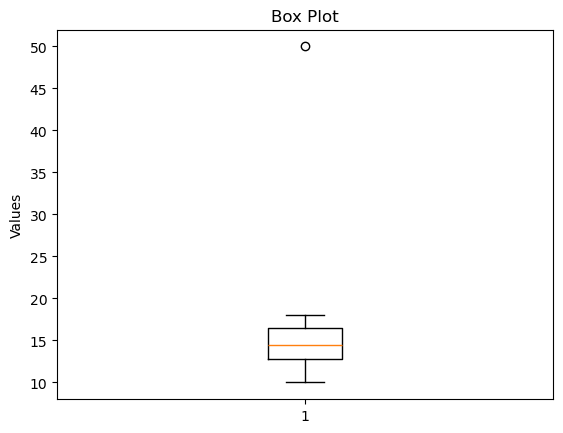

In [45]:
import matplotlib.pyplot as plt

data = [10, 12, 13, 14, 15, 16, 18, 50]

plt.boxplot(data)
plt.ylabel("Values")
plt.title("Box Plot")
plt.show()

#Points outside the whiskers are generally shown as potential outliers.

### Scatter Plot
A Scatter Plot displays individual data points and helps identify observations that are far from the rest.

Example:

The mark 150 appears much higher than all other students.

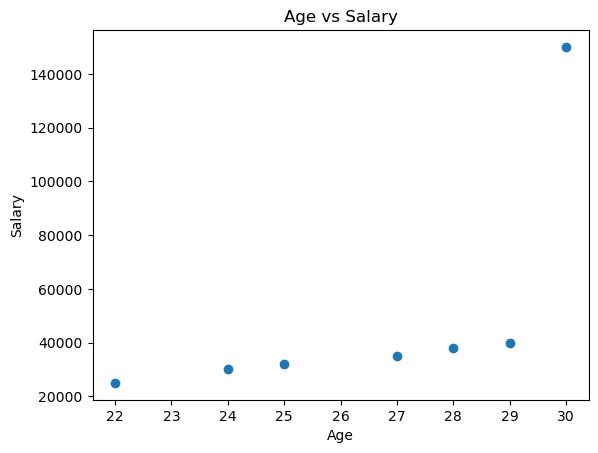

In [43]:
import matplotlib.pyplot as plt

age = [22, 24, 25, 27, 28, 29, 30]
salary = [25000, 30000, 32000, 35000, 38000, 40000, 150000]

plt.scatter(age, salary)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.show()
#The scatter plot helps us visually identify unusual observations.